<a href="https://colab.research.google.com/github/FerFilho23/Machine-Learning/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures

[[4.36736974]
 [2.66162223]]


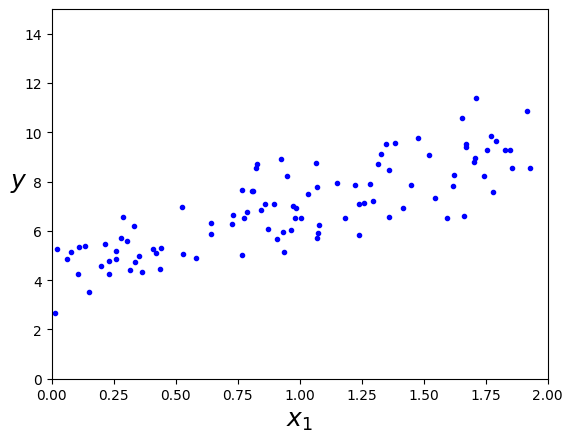

In [2]:
# Training Models
## Linear Regresssion

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(theta_best)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

In [3]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.36736974],
       [9.69061419]])

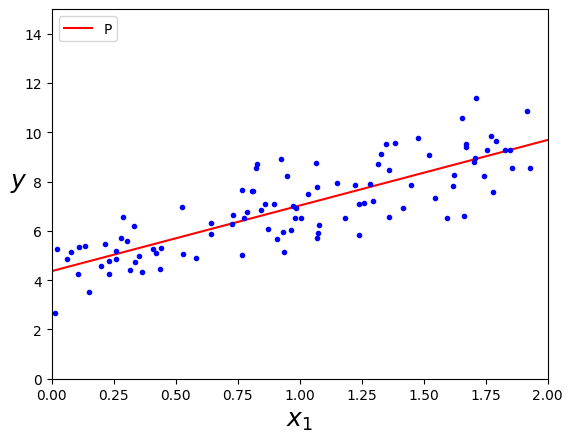

In [4]:
plt.plot(X_new, y_predict, "r-")
plt.legend("Predictions", loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [5]:
#Scikit-Learn: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.36736974]), array([[2.66162223]]))

In [6]:
lin_reg.predict(X_new)

array([[4.36736974],
       [9.69061419]])

In [7]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.36736974],
       [2.66162223]])

In [8]:
# Gradient Descent in Batch
eta= 0.1  # learning rate
n_iterations = 1000
m = 100

theta = np.random.randn(2,1)  # random initialization

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

theta

array([[4.36736974],
       [2.66162223]])

In [10]:
# Stochastic Gradient Descent
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)  # random initialization

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

theta

array([[4.30700453],
       [2.72981298]])

In [13]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([4.41027146]), array([2.73026809]))

# 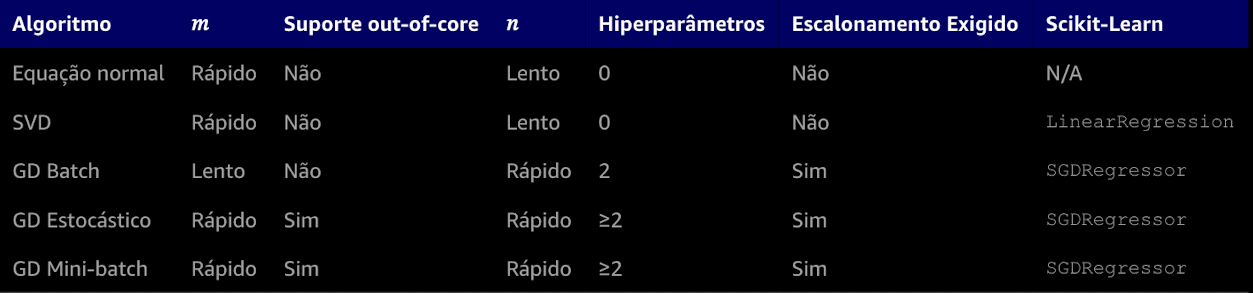

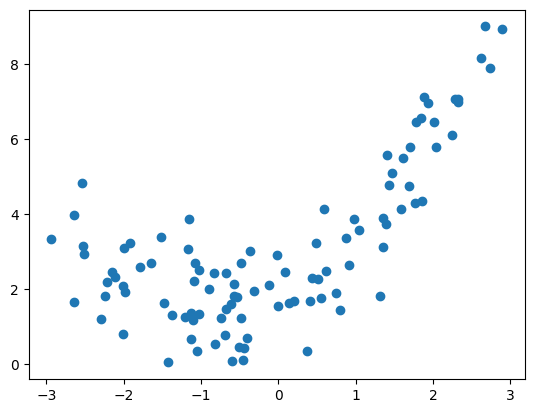

In [14]:
# Polynomial Regression
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

plt.scatter(X, y)

In [17]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

[0.7937794]
[0.7937794  0.63008573]


In [25]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_



(array([1.85856193]), array([[0.93453713, 0.5569164 ]]))

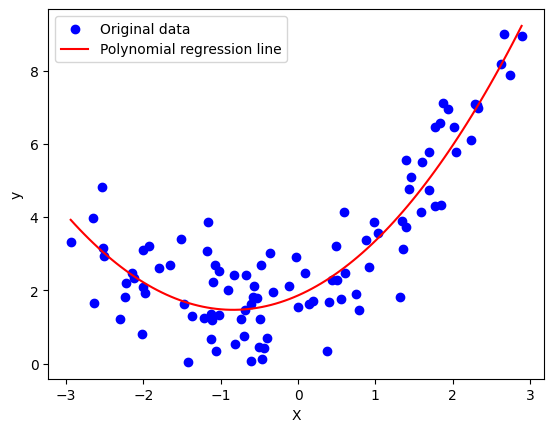

In [38]:
# Assuming X and y are already defined

# Generate a range of values for X to plot the polynomial regression line smoothly
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Step 2: Use the PolynomialFeatures transformer to transform these values
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_range_poly = poly_features.fit_transform(X_range)

# Step 3: Predict the target values using the trained linear regression model
y_range_pred = lin_reg.predict(X_range_poly)

# Step 4: Plot the original data and the polynomial regression line
plt.scatter(X, y, color='blue', label='Original data')
plt.plot(X_range, y_range_pred, color='red', label='Polynomial regression line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()